<a href="https://colab.research.google.com/github/alfonsorinconbarrera/alfonsorinconbarrera/blob/main/Diagrama_Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

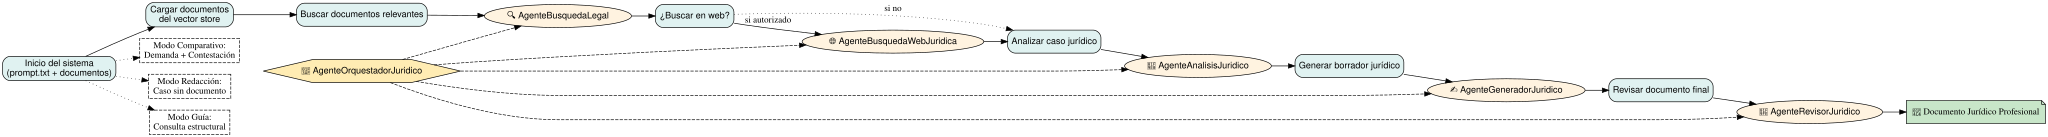

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Instalar Graphviz si no está
!pip install graphviz

from graphviz import Digraph
from IPython.display import SVG, display
from google.colab import files

# Crear grafo en formato SVG
g = Digraph("SistemaMultiagenteJuridico", format='svg')
g.attr(rankdir='LR', fontsize="12")

style_default = {"shape": "box", "style": "rounded,filled", "fillcolor": "#E0F2F1", "fontname": "Helvetica"}
style_agente = {"shape": "ellipse", "style": "filled", "fillcolor": "#FFF3E0", "fontname": "Helvetica"}
style_orquestador = {"shape": "hexagon", "style": "filled", "fillcolor": "#FFECB3", "fontname": "Helvetica"}

# Nodos del flujo general
g.node("Inicio", "Inicio del sistema\n(prompt.txt + documentos)", **style_default)
g.node("VectorStore", "Cargar documentos\ndel vector store", **style_default)
g.node("Busqueda", "Buscar documentos relevantes", **style_default)
g.node("WebOpcional", "¿Buscar en web?", **style_default)
g.node("Analisis", "Analizar caso jurídico", **style_default)
g.node("Generacion", "Generar borrador jurídico", **style_default)
g.node("Revision", "Revisar documento final", **style_default)
g.node("Fin", "📄 Documento Jurídico Profesional", shape="note", style="filled", fillcolor="#C8E6C9")

# Modo de trabajo
g.node("Modo1", "Modo Comparativo:\nDemanda + Contestación", shape="box", style="dashed", fillcolor="#F1F8E9")
g.node("Modo2", "Modo Redacción:\nCaso sin documento", shape="box", style="dashed", fillcolor="#F1F8E9")
g.node("Modo3", "Modo Guía:\nConsulta estructural", shape="box", style="dashed", fillcolor="#F1F8E9")

# Agentes
g.node("AgenteOrquestador", "🎯 AgenteOrquestadorJuridico", **style_orquestador)
g.node("AgenteBusqueda", "🔍 AgenteBusquedaLegal", **style_agente)
g.node("AgenteWeb", "🌐 AgenteBusquedaWebJuridica", **style_agente)
g.node("AgenteAnalisis", "🧠 AgenteAnalisisJuridico", **style_agente)
g.node("AgenteGenerador", "✍️ AgenteGeneradorJuridico", **style_agente)
g.node("AgenteRevisor", "🧾 AgenteRevisorJuridico", **style_agente)

# Flujo principal
g.edge("Inicio", "VectorStore")
g.edge("VectorStore", "Busqueda")
g.edge("Busqueda", "AgenteBusqueda")
g.edge("AgenteBusqueda", "WebOpcional")
g.edge("WebOpcional", "AgenteWeb", label="si autorizado")
g.edge("WebOpcional", "Analisis", label="si no", style="dotted")
g.edge("AgenteWeb", "Analisis")
g.edge("Analisis", "AgenteAnalisis")
g.edge("AgenteAnalisis", "Generacion")
g.edge("Generacion", "AgenteGenerador")
g.edge("AgenteGenerador", "Revision")
g.edge("Revision", "AgenteRevisor")
g.edge("AgenteRevisor", "Fin")

# Orquestador activa cada agente
g.edge("AgenteOrquestador", "AgenteBusqueda", style="dashed")
g.edge("AgenteOrquestador", "AgenteWeb", style="dashed")
g.edge("AgenteOrquestador", "AgenteAnalisis", style="dashed")
g.edge("AgenteOrquestador", "AgenteGenerador", style="dashed")
g.edge("AgenteOrquestador", "AgenteRevisor", style="dashed")

# Modos
g.edge("Inicio", "Modo1", style="dotted")
g.edge("Inicio", "Modo2", style="dotted")
g.edge("Inicio", "Modo3", style="dotted")

# Renderizar SVG
nombre_archivo = "sistema_multiagente_juridico_con_orquestador"
svg_path = g.render(nombre_archivo, view=False)

# Mostrar en notebook
display(SVG(svg_path))

# Ofrecer descarga
files.download(svg_path)